# Phase 1: Context Extraction via CLIP
**Goal:** In order to build a context-aware photo editor, the model needs to understand what is in the photo (e.g., a street scene vs. a sunset).

*   Here, we use a pretrained Vision Transformer (CLIP ViT-B-32) to map raw images into a 512-dimensional embedding space.
*   These embeddings will serve as the input condition for our future LUT prediction network.



In [ ]:
# Install dependencies if needed
!pip install open_clip_torch Pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00


In [ ]:
# Mount Drive and access images
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/photo-style-rl'

Mounted at /content/drive


In [ ]:
# Check images are there
import os
raw_images = sorted(os.listdir(f'{PROJECT}/images/raw'))
edited_images = sorted(os.listdir(f'{PROJECT}/images/edited'))
print(f"Found {len(raw_images)} raw images:")
for img in raw_images:
    print(f"  {img}")
print(f"\nFound {len(edited_images)} edited images:")
for img in edited_images:
    print(f"  {img}")

Found 12 raw images:
  test_01_raw.jpg
  test_02_raw.jpg
  test_03_raw.jpg
  test_04_raw.jpg
  test_05_raw.jpg
  test_06_raw.jpg
  test_07_raw.jpg
  test_08_raw.jpg
  test_09_raw.jpg
  test_10_raw.jpg
  test_11_raw.jpg
  test_12_raw.jpg

Found 12 edited images:
  test_01_edited.jpg
  test_02_edited.jpg
  test_03_edited.jpg
  test_04_edited.jpg
  test_05_edited.jpg
  test_06_edited.jpg
  test_07_edited.jpg
  test_08_edited.jpg
  test_09_edited.jpg
  test_10_edited.jpg
  test_11_edited.jpg
  test_12_edited.jpg


In [ ]:
# Verify GPU access
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Model Initialization & Data Ingestion
We are using OpenCLIP with weights trained on the LAION dataset. The `preprocess` function automatically handles the resizing (224x224) and normalization required by the Vision Transformer. We also load our 12 sample RAW images to visualize our working dataset.

CLIP model loaded


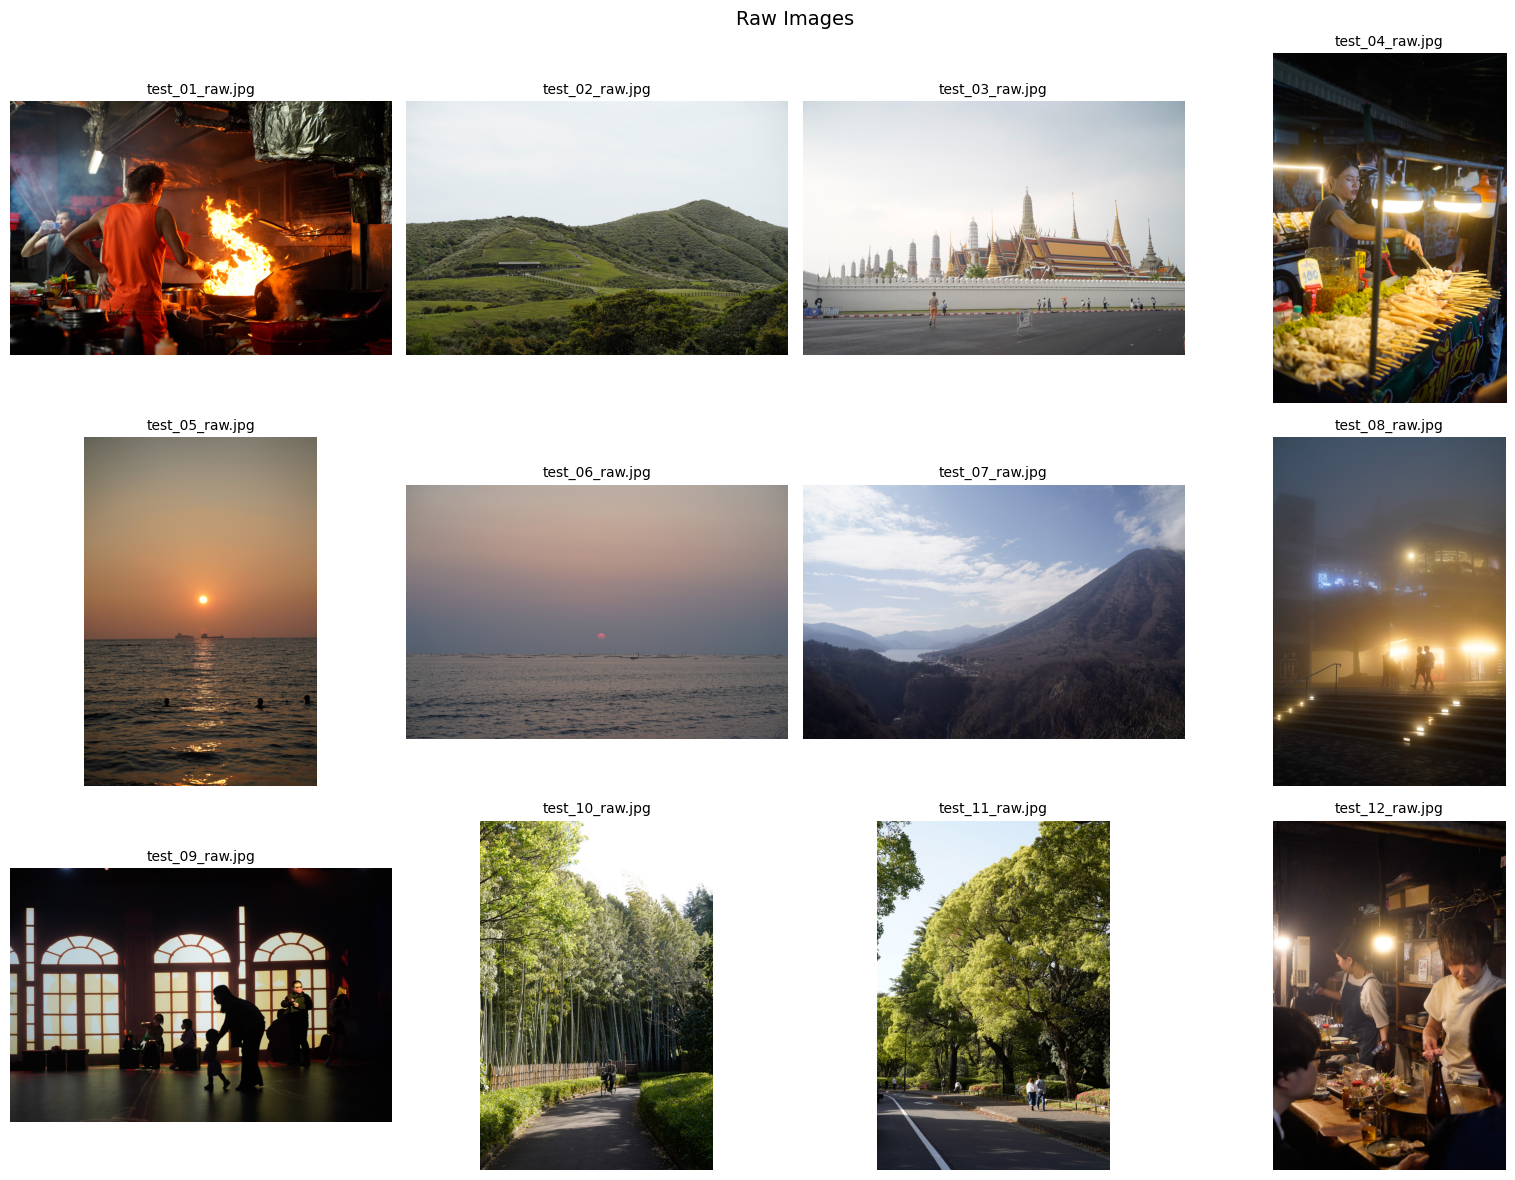

Loaded 12 raw images


In [ ]:
import open_clip
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load CLIP model
# model is the neural network, _ the tokenizer, and preprocess the function that normalizes images
# ViT-B-32: Vision Transformer, Base size, 32x32 patch size.
# laion2b_s34b_b79k = pretrained weights from the LAION dataset
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='laion2b_s34b_b79k'
)
# .eval() puts the model in evaluation mode since we're only analyzing, not training
# .cuda() moves model from CPU to GPU memory
model = model.eval().cuda()
print("CLIP model loaded")

# Load all test images
raw_dir = f'{PROJECT}/images/raw'
edited_dir = f'{PROJECT}/images/edited'
# filters for only .jpg files and sorts them
raw_files = sorted([f for f in os.listdir(raw_dir) if f.endswith('.jpg')])
edited_files = sorted([f for f in os.listdir(edited_dir) if f.endswith('.jpg')])

# creates a 3x4 grid of image plots
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
# turns the 2D grid of axes into a flat list so we can loop through them with a single index
axes = axes.flatten()

# Loop through test images and display
for i, filename in enumerate(raw_files):
    img = Image.open(os.path.join(raw_dir, filename))
    axes[i].imshow(img)
    axes[i].set_title(filename, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Raw Images', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Loaded {len(raw_files)} raw images")

## 2. Feature Extraction (Forward Pass)
We process each image through the CLIP image encoder. To optimize memory usage on the GPU, we use `torch.no_grad()` to disable gradient tracking, as we are strictly performing inference. The output is a dictionary of 512-dimensional vectors keyed by filename.

In [ ]:
import torch

# Extract embeddings from test images, keyed by file name
raw_embeddings = {}
edited_embeddings = {}

print("Extracting raw embeddings:")
for filename in raw_files:
    img = Image.open(os.path.join(raw_dir, filename))
    # preprocess(img) resizes and normalizes the image to what CLIP expects (224x224)
    # .unsqueeze() adds a batch dimension since model expects [batch_size, channels, height, width]
    img_tensor = preprocess(img).unsqueeze(0).cuda()

    # Tells PyTorch not to track gradients since we're not traning, just extracting features
    with torch.no_grad():
        # runs the image through CLIP and returns the embedding vector
        emb = model.encode_image(img_tensor)
    # .cpu().squeeze() moves the results back to CPU memory and removes the batch dimension
    raw_embeddings[filename] = emb.cpu().squeeze(0)
    print(f"  {filename}: {emb.shape}")

print("\nExtracting edited embeddings:")
for filename in edited_files:
    img = Image.open(os.path.join(edited_dir, filename))
    img_tensor = preprocess(img).unsqueeze(0).cuda()
    with torch.no_grad():
        emb = model.encode_image(img_tensor)
    edited_embeddings[filename] = emb.cpu().squeeze(0)
    print(f"  {filename}: {emb.shape}")

print(f"\nExtracted {len(raw_embeddings)} raw + {len(edited_embeddings)} edited embeddings")

Extracting raw embeddings:
  test_01_raw.jpg: torch.Size([1, 512])
  test_02_raw.jpg: torch.Size([1, 512])
  test_03_raw.jpg: torch.Size([1, 512])
  test_04_raw.jpg: torch.Size([1, 512])
  test_05_raw.jpg: torch.Size([1, 512])
  test_06_raw.jpg: torch.Size([1, 512])
  test_07_raw.jpg: torch.Size([1, 512])
  test_08_raw.jpg: torch.Size([1, 512])
  test_09_raw.jpg: torch.Size([1, 512])
  test_10_raw.jpg: torch.Size([1, 512])
  test_11_raw.jpg: torch.Size([1, 512])
  test_12_raw.jpg: torch.Size([1, 512])

Extracting edited embeddings:
  test_01_edited.jpg: torch.Size([1, 512])
  test_02_edited.jpg: torch.Size([1, 512])
  test_03_edited.jpg: torch.Size([1, 512])
  test_04_edited.jpg: torch.Size([1, 512])
  test_05_edited.jpg: torch.Size([1, 512])
  test_06_edited.jpg: torch.Size([1, 512])
  test_07_edited.jpg: torch.Size([1, 512])
  test_08_edited.jpg: torch.Size([1, 512])
  test_09_edited.jpg: torch.Size([1, 512])
  test_10_edited.jpg: torch.Size([1, 512])
  test_11_edited.jpg: torch.Size

## 3. Verifying Embeddings: Cosine Similarity
To ensure the embeddings actually capture semantic meaning, we calculate the cosine similarity between every pair of photos. By normalizing the vectors and computing their dot product, we generate a heatmap. We expect visually similar photos (like two sunsets) to cluster with higher similarity scores (closer to 1.0).

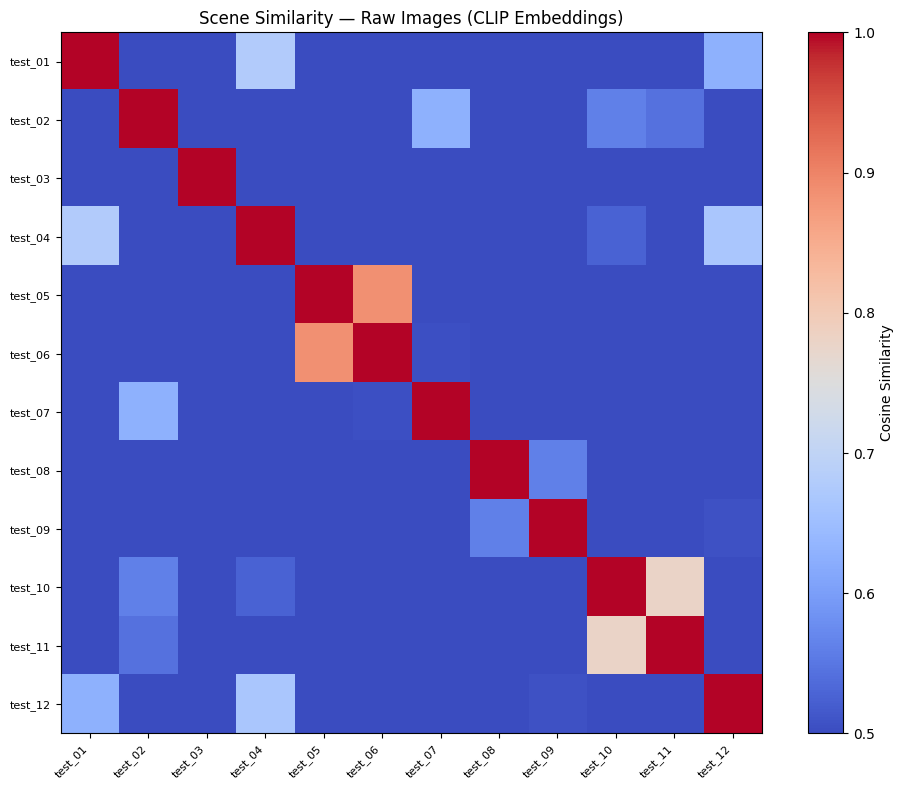

In [ ]:
import torch.nn.functional as F

# Compute how visually similar CLIP thinks each pair of photos are
# - use raw embeddings for the heatmap since that represents actual scene content
# normalize embeddings
emb_matrix = torch.stack(list(raw_embeddings.values()))
emb_matrix = F.normalize(emb_matrix, dim=1)

# compute cosine similarity between all pairs
similarity = emb_matrix @ emb_matrix.T

# display as heatmap
plt.figure(figsize=(10, 8))
plt.imshow(similarity.numpy(), cmap='coolwarm', vmin=0.5, vmax=1.0)
labels = [f.replace('_raw.jpg','') for f in raw_files]
plt.xticks(range(len(raw_files)), labels, rotation=45, ha='right', fontsize=8)
plt.yticks(range(len(raw_files)), labels, fontsize=8)
plt.colorbar(label='Cosine Similarity')
plt.title('Scene Similarity — Raw Images (CLIP Embeddings)')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Save both embedding sets
pickle.dump(raw_embeddings, open(f'{PROJECT}/checkpoints/clip_embeddings_raw.pkl', 'wb'))
pickle.dump(edited_embeddings, open(f'{PROJECT}/checkpoints/clip_embeddings_edited.pkl', 'wb'))

print(f"Saved {len(raw_embeddings)} raw embeddings")
print(f"Saved {len(edited_embeddings)} edited embeddings")

Removed outdated /content/drive/MyDrive/photo-style-rl/checkpoints/clip_embeddings.pkl
Saved 12 raw embeddings
Saved 12 edited embeddings


In [ ]:
# Compare how much our edits shift each image in embedding space
print("How much do your edits change each image's embedding?\n")

for raw_f, edited_f in zip(sorted(raw_embeddings.keys()), sorted(edited_embeddings.keys())):
    raw_emb = F.normalize(raw_embeddings[raw_f].unsqueeze(0), dim=1)
    edited_emb = F.normalize(edited_embeddings[edited_f].unsqueeze(0), dim=1)
    similarity = (raw_emb @ edited_emb.T).item()
    shift = 1 - similarity
    print(f"  {raw_f} -> {edited_f}: similarity={similarity:.4f}, shift={shift:.4f}")

How much do your edits change each image's embedding?

  test_01_raw.jpg -> test_01_edited.jpg: similarity=0.9707, shift=0.0293
  test_02_raw.jpg -> test_02_edited.jpg: similarity=0.9231, shift=0.0769
  test_03_raw.jpg -> test_03_edited.jpg: similarity=0.9510, shift=0.0490
  test_04_raw.jpg -> test_04_edited.jpg: similarity=0.9798, shift=0.0202
  test_05_raw.jpg -> test_05_edited.jpg: similarity=0.9447, shift=0.0553
  test_06_raw.jpg -> test_06_edited.jpg: similarity=0.9271, shift=0.0729
  test_07_raw.jpg -> test_07_edited.jpg: similarity=0.9466, shift=0.0534
  test_08_raw.jpg -> test_08_edited.jpg: similarity=0.9543, shift=0.0457
  test_09_raw.jpg -> test_09_edited.jpg: similarity=0.8977, shift=0.1023
  test_10_raw.jpg -> test_10_edited.jpg: similarity=0.9538, shift=0.0462
  test_11_raw.jpg -> test_11_edited.jpg: similarity=0.9392, shift=0.0608
  test_12_raw.jpg -> test_12_edited.jpg: similarity=0.9708, shift=0.0292


## 4. Exploratory - Zero-Shot Image Classification
Because CLIP was trained on image-text pairs, we can test its understanding of our dataset by comparing our image embeddings against text embeddings. We define four distinct photographic categories and measure which text prompt has the highest cosine similarity to each image.

In [ ]:
# gets the tokenizer that matches the CLIP model
# tokenizer converts human-reading text into numbers (tokens) that the model can process
tokenizer = open_clip.get_tokenizer('ViT-B-32')

# Define categories we care about
categories = [
    "a sunset or sunrise photo",
    "a portrait of a person",
    "a landscape or nature photo",
    "a street or urban photo"
]

# Encode text categories
# convert all text strings above into token tensors and move them to GPU
text_tokens = tokenizer(categories).cuda()
# runs the text through CLIP's text encoder (same model, but the text side of it)
with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    # scales each vector to unit length, required for cosine similarity to work
    text_features = F.normalize(text_features, dim=1)

# Classify each image
print("Auto-categorization of your photos:\n")
# loops through each image
for filename in raw_files:
    # grab the embedding from the earlier dict, add a batch dimension, and normalize
    emb = F.normalize(raw_embeddings[filename].unsqueeze(0), dim=1)
    # the actual similarity computation, @ is matrix mult, so one similarity score per category
    scores = (emb @ text_features.cpu().T).squeeze(0)
    # finds index of the highest score, so which category matched best
    best = scores.argmax().item()
    # print filename, winning category name, and the confidence score
    print(f"  {filename}: {categories[best]} ({scores[best]:.3f})")

Auto-categorization of your photos:

  test_01_raw.jpg: a street or urban photo (0.159)
  test_02_raw.jpg: a landscape or nature photo (0.277)
  test_03_raw.jpg: a street or urban photo (0.228)
  test_04_raw.jpg: a street or urban photo (0.163)
  test_05_raw.jpg: a sunset or sunrise photo (0.293)
  test_06_raw.jpg: a sunset or sunrise photo (0.307)
  test_07_raw.jpg: a landscape or nature photo (0.268)
  test_08_raw.jpg: a street or urban photo (0.198)
  test_09_raw.jpg: a street or urban photo (0.178)
  test_10_raw.jpg: a landscape or nature photo (0.203)
  test_11_raw.jpg: a landscape or nature photo (0.218)
  test_12_raw.jpg: a portrait of a person (0.135)


## 5. Metadata Construction & Checkpointing
Finally, we attach manual ground-truth tags and descriptions to our images. We serialize both the image metadata and the 512-dimensional CLIP embeddings to Google Drive. These artifacts will be ingested by the LUT prediction network in Notebook 02.

In [ ]:
import json

image_metadata = {
    "test_01": {"description": "food hawker in orange tank top cooking in Hong Kong street, huge fire, dark ambiance", "tags": ["street", "food", "people", "dramatic_light"]},
    "test_02": {"description": "landscape of mountains", "tags": ["landscape", "nature"]},
    "test_03": {"description": "Thai temples in Bangkok landmark", "tags": ["street", "architecture", "travel"]},
    "test_04": {"description": "street food vendor portrait handling food", "tags": ["street", "food", "people"]},
    "test_05": {"description": "dramatic ocean sunset with ship on horizon, two people in water", "tags": ["sunset", "people", "dramatic_light"]},
    "test_06": {"description": "dusk sunset with red cyberwave sun", "tags": ["sunset", "dramatic_light"]},
    "test_07": {"description": "mountain and lake landscape", "tags": ["landscape", "nature"]},
    "test_08": {"description": "street photo with dramatic fog and soft lighting", "tags": ["street", "dramatic_light", "atmosphere"]},
    "test_09": {"description": "backlit mother walking with daughter, silhouettes", "tags": ["street", "people", "dramatic_light", "silhouette"]},
    "test_10": {"description": "man biking along park path with trees", "tags": ["street", "people", "nature"]},
    "test_11": {"description": "couple illuminated in shadows walking on sidewalk with trees", "tags": ["street", "people", "dramatic_light"]},
    "test_12": {"description": "intimate bar scene, chef cooking for customers", "tags": ["street", "food", "people", "atmosphere"]}
}

metadata_path = f'{PROJECT}/image_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(image_metadata, f, indent=2)
print(f"Saved metadata to {metadata_path}")

Saved metadata to /content/drive/MyDrive/photo-style-rl/image_metadata.json


In [ ]:
import pickle

# Embeddings
pickle.dump(raw_embeddings, open(f'{PROJECT}/checkpoints/clip_embeddings.pkl', 'wb'))

# Summary
print("Session complete. Saved to Drive:")
print(f"  Embeddings: {PROJECT}/checkpoints/clip_embeddings.pkl")
print(f"  Metadata:   {PROJECT}/image_metadata.json")

Session complete. Saved to Drive:
  Embeddings: /content/drive/MyDrive/photo-style-rl/checkpoints/clip_embeddings.pkl
  Metadata:   /content/drive/MyDrive/photo-style-rl/image_metadata.json
